In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from datetime import datetime

In [3]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [4]:
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

### Calculate distance between client and merch where there card was been used

In [5]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    km = 6371 * c
    return km


In [6]:
def data_processing(df_path):
    df = pd.read_csv(df_path)
    df.drop(df.columns[0], axis=1, inplace=True)
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    df['year'] = df['trans_date_trans_time'].dt.year
    df['month'] = df['trans_date_trans_time'].dt.month
    df['day'] = df['trans_date_trans_time'].dt.day
    df['time'] = df['trans_date_trans_time'].dt.time
    
    df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')
    
    # Ensure 'dob' is in datetime format
    df['dob'] = pd.to_datetime(df['dob'])

    # Calculate age and create a new 'age' column
    df['age'] = df['dob'].apply(calculate_age)
    
    # Calculate distance and create a new 'distance_km' column
    df['dist_client_merch'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)
    
    le = LabelEncoder()
    df['le_gender'] = le.fit_transform(df['gender'])
    
    te = TargetEncoder()
    te_job = te.fit_transform(df['job'].array.reshape(-1, 1), df['is_fraud'])
    df['te_job'] = te_job
    te_street = te.fit_transform(df['street'].array.reshape(-1, 1), df['is_fraud'])
    df['te_street'] = te_street
    te_merchant = te.fit_transform(df['merchant'].array.reshape(-1, 1), df['is_fraud'])
    df['te_merchant'] = te_merchant
    te_city = te.fit_transform(df['city'].array.reshape(-1, 1), df['is_fraud'])
    df['te_city'] = te_city
    te_state = te.fit_transform(df['state'].array.reshape(-1, 1), df['is_fraud'])
    df['te_state'] = te_state
    te_category = te.fit_transform(df['category'].array.reshape(-1, 1), df['is_fraud'])
    df['te_category'] = te_category
    
    return df
    
    
    

In [7]:
df = data_processing('../fraudTrain.csv')

In [8]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,le_gender,te_job,te_street,te_merchant,te_city,te_state,te_category
829999,2019-12-10 18:33:22,4195740185974,fraud_Kozey-Kuhlman,personal_care,44.44,Benjamin,Robinson,M,0701 John Ranch,Portland,OR,97210,45.5303,-122.7033,841711,"Engineer, building services",1963-04-04,681c0ecead1574f4cda881bea6c88462,1355164402,45.481037,-122.640735,0,2019,12,10,1900-01-01 18:33:22,61,7.333377,1,0.007387,0.0,0.003386,0.0,0.00831,0.002343


In [9]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'job', 'first', 'last', 'lat', 'long', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num', 'merch_lat', 'merch_long', 'dob'
]

# Create a new DataFrame by dropping the specified columns
df_1 = df.drop(columns=columns_to_drop)

In [10]:
df_1.sample()

,amt,zip,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,te_job,te_street,te_merchant,te_city,te_state,te_category
854811,48.96,29809,2206,1355642375,0,2019,12,16,37,113.245925,0,0.006477,0.009027,0.005216,0.009774,0.006693,0.004819


In [11]:
df_1.corr()

,amt,zip,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,te_job,te_street,te_merchant,te_city,te_state,te_category
amt,1.000000,0.001843,0.005818,-0.000293,0.219404,0.000842,-0.001748,0.000629,-0.009823,-0.001085,0.001034,0.041268,0.078721,0.092027,0.070014,0.007259,0.097980
zip,0.001843,1.000000,0.078467,0.000670,-0.002162,0.000086,0.000852,-0.000607,0.010419,0.006183,-0.065951,-0.007596,-0.006734,0.005129,-0.006132,-0.056480,0.005206
city_pop,0.005818,0.078467,1.000000,-0.001714,0.002136,-0.001673,0.000137,0.000159,-0.094043,0.010901,-0.028649,0.003523,0.006590,0.000462,0.006660,-0.011869,0.000593
unix_time,-0.000293,0.000670,-0.001714,1.000000,-0.005078,0.782582,0.184868,0.017162,-0.003637,-0.000633,-0.000960,-0.001686,-0.003410,0.000217,-0.003716,-0.002112,0.000180
is_fraud,0.219404,-0.002162,0.002136,-0.005078,1.000000,0.003004,-0.012409,0.003848,0.012401,0.000403,0.007642,0.170686,0.317752,0.065655,0.281026,0.036775,0.070589
year,0.000842,0.000086,-0.001673,0.782582,0.003004,1.000000,-0.464879,-0.045759,-0.004397,-0.000595,-0.000654,-0.004333,-0.000093,0.001632,0.000122,-0.001373,0.001634
month,-0.001748,0.000852,0.000137,0.184868,-0.012409,-0.464879,1.000000,0.012434,0.002212,0.000098,-0.000215,0.004508,-0.005163,-0.001355,-0.005728,-0.001129,-0.001370
day,0.000629,-0.000607,0.000159,0.017162,0.003848,-0.045759,0.012434,1.000000,0.000575,-0.000594,-0.000206,-0.000407,0.005183,0.000751,0.002751,0.003670,0.001011
age,-0.009823,0.010419,-0.094043,-0.003637,0.012401,-0.004397,0.002212,0.000575,1.000000,-0.004614,0.007353,0.031958,0.038527,-0.000893,0.034428,0.019320,-0.001428
dist_client_merch,-0.001085,0.006183,0.010901,-0.000633,0.000403,-0.000595,0.000098,-0.000594,-0.004614,1.000000,-0.002394,0.000883,0.000028,0.000763,-0.000093,-0.005233,0.001072


In [11]:
df_test = data_processing('../fraudTest.csv')

In [12]:
df_2 = df_test.drop(columns=columns_to_drop)

In [13]:
df_2.sample()

,amt,zip,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,te_job,te_street,te_merchant,te_city,te_state,te_category
224342,55.4,17051,4653,1378679759,0,2020,9,8,27,93.206516,1,0.0,0.0,0.006978,0.0,0.003288,0.00951


# Model Development

In [14]:
X = df_1.drop(columns=['is_fraud'])  # Features
y = df_1['is_fraud'] 

In [15]:
X_test_actual = df_2.drop(columns=['is_fraud'])  # Features
y_test_actual = df_2['is_fraud'] 

## Data Split

In [16]:
from sklearn.model_selection import train_test_split


In [17]:
X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(X, y, test_size=0.2, random_state=40)


In [18]:
print("X_train_unbalanced shape:", X_train_unbalanced.shape)
print("X_test_unbalanced shape:", X_test_unbalanced.shape)
print("y_train_unbalanced shape:", y_train_unbalanced.shape)
print("y_test_unbalanced shape:", y_test_unbalanced.shape)

X_train_unbalanced shape: (1037340, 16)
X_test_unbalanced shape: (259335, 16)
y_train_unbalanced shape: (1037340,)
y_test_unbalanced shape: (259335,)


In [19]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


## Model without balancing

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [21]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

In [22]:
lr.fit(X,y)
y_pred_lr = lr.predict(X_test_actual)
y_prob_lr = lr.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9955139198047934
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719

ROC AUC Score: 0.8277677651416303


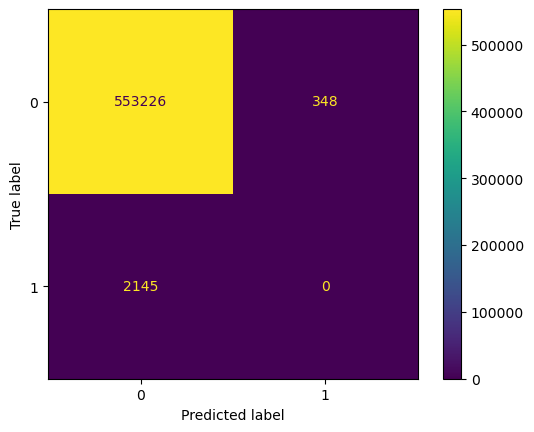

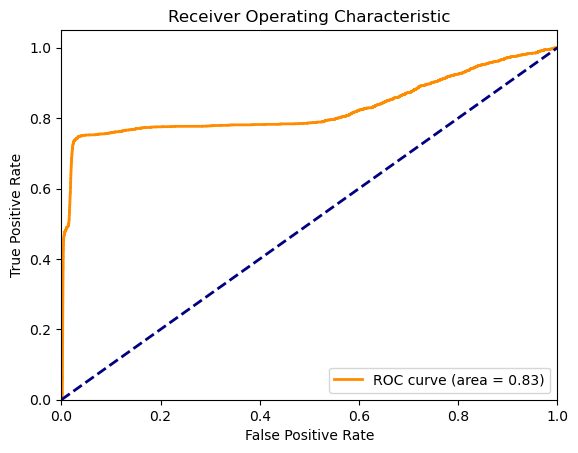

In [23]:
measure_metrics(y_test_actual, y_pred_lr, y_prob_lr)

In [24]:
dt.fit(X, y)
y_pred_dt = dt.predict(X_test_actual)
y_prob_dt = dt.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.919443099840027
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    553574
           1       0.02      0.36      0.03      2145

    accuracy                           0.92    555719
   macro avg       0.51      0.64      0.50    555719
weighted avg       0.99      0.92      0.95    555719

ROC AUC Score: 0.6402945873495429


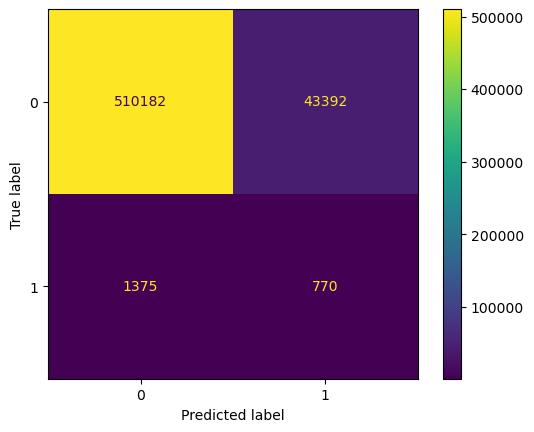

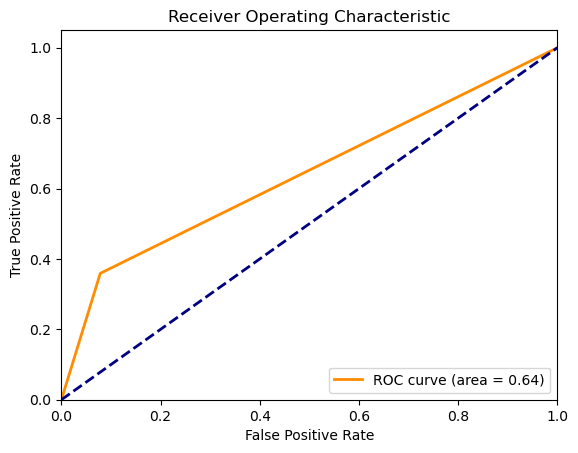

In [25]:
measure_metrics(y_test_actual, y_pred_dt, y_prob_dt)

In [ ]:
rf.fit(X, y)
y_pred_rf = rf.predict(X_test_actual)
y_prob_rf = rf.predict_proba(X_test_actual)[:, 1]

In [ ]:
measure_metrics(y_test_actual, y_pred_rf, y_prob_rf)

## Model with balancing

In [26]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Resample the dataset
X_train_smote, y_train_smote = smote.fit_resample(X, y)

### Logistic Regression

In [27]:
lr.fit(X_train_smote,y_train_smote)
y_pred_lr_smote = lr.predict(X_test_actual)
y_prob_lr_smote = lr.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9557996037565748
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.06      0.75      0.12      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719

ROC AUC Score: 0.8329497576431139


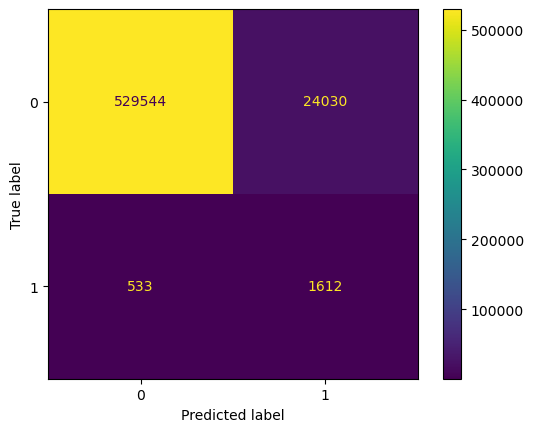

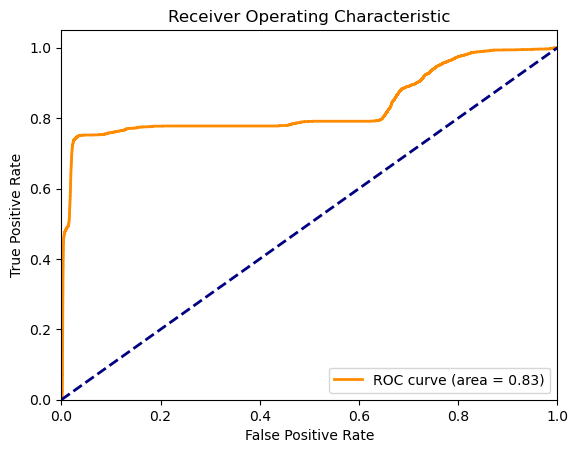

In [28]:
measure_metrics(y_test_actual, y_pred_lr_smote, y_prob_lr_smote)

#### Cross validation - LR

In [33]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import numpy as np

# Instantiate the logistic regression model
lr = LogisticRegression(max_iter=1000)
skf = StratifiedKFold(n_splits=5)
# Perform cross-validation with precision as the scoring metric
cv_scores_precision = cross_val_score(lr, X_train_smote, y_train_smote, cv=skf, scoring='precision')

print("Cross-validation precision scores: ", cv_scores_precision)
print("Mean cross-validation precision score: ", np.mean(cv_scores_precision))
print("Standard deviation of cross-validation precision score: ", np.std(cv_scores_precision))


KeyboardInterrupt: 

In [ ]:
# Perform cross-validation with recall as the scoring metric
cv_scores_recall = cross_val_score(lr, X_train_smote, y_train_smote, cv=5, scoring='recall')

print("Cross-validation recall scores: ", cv_scores_recall)
print("Mean cross-validation recall score: ", np.mean(cv_scores_recall))
print("Standard deviation of cross-validation recall score: ", np.std(cv_scores_recall))

In [29]:
lr.fit(X_train_smote,y_train_smote)
y_pred_lr_smote_cv = lr.predict(X_test_actual)
y_prob_lr_smote_cv = lr.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9557996037565748
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.06      0.75      0.12      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719

ROC AUC Score: 0.8329497576431139


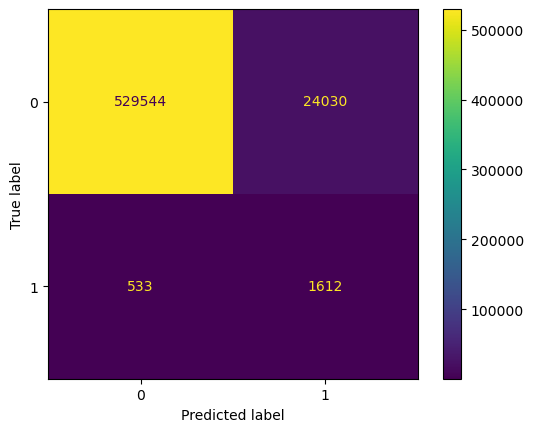

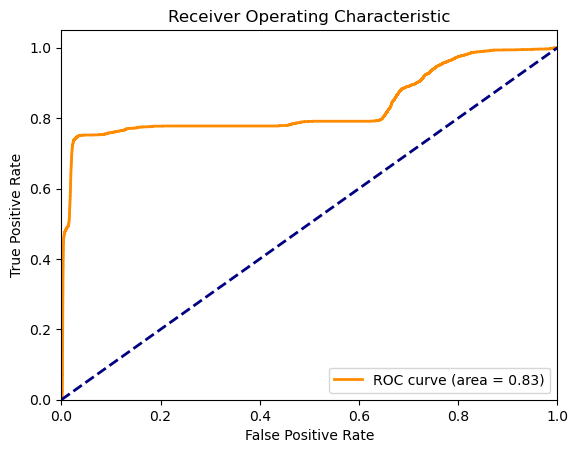

In [30]:
measure_metrics(y_test_actual, y_pred_lr_smote_cv, y_prob_lr_smote_cv)

#### Hyperpparameter tuning LR

In [ ]:
random_search_lr = {
    'penalty': ['l1','l2','elasticnet','none'],
    'solver': ['newton-cg','lbfgs','liblinear','sag','saga'],
    'max_iter': list(np.linspace(5, 1000, 10, dtype = int)),
}

In [29]:
from sklearn.model_selection import RandomizedSearchCV
cv_lr = LogisticRegression(max_iter=10000)

In [ ]:
model_lr = RandomizedSearchCV(estimator = cv_lr, param_distributions = random_search_lr, cv = 4, verbose= 5, random_state= 101, scoring='recall')


In [ ]:
# fit logistic regression model with CV 
model_lr.fit(X_train_smote, y_train_smote)
model_lr.best_params_

##### Parameter tuned

In [31]:
para_tuned_lr = LogisticRegression(max_iter=778, penalty = 'l2', solver='newton-cg')

In [32]:
para_tuned_lr.fit(X_train_smote, y_train_smote)
y_pred_lr_smote_tuned = para_tuned_lr.predict(X_test_actual)
y_prob_lr_smote_tuned = para_tuned_lr.predict_proba(X_test_actual)[:, 1]

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/scipy/optimize/_linesearch.py:466: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/scipy/optimize/_linesearch.py:314: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/utils/optimize.py:311: UserWarning: Line Search failed
  warnings.warn("Line Search failed")


Accuracy: 0.9660727813877157
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.08      0.75      0.15      2145

    accuracy                           0.97    555719
   macro avg       0.54      0.86      0.56    555719
weighted avg       1.00      0.97      0.98    555719

ROC AUC Score: 0.8289407000946921


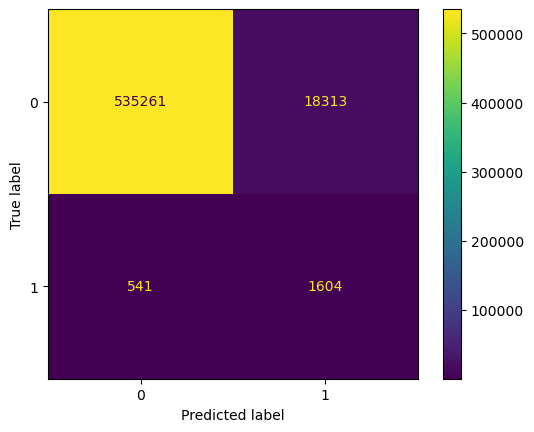

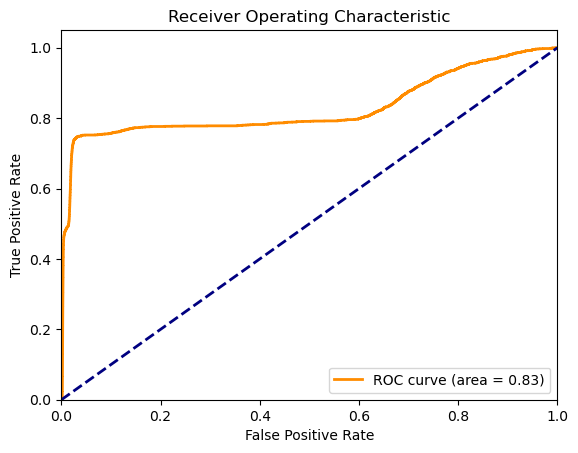

In [33]:
measure_metrics(y_test_actual, y_pred_lr_smote_tuned, y_prob_lr_smote_tuned)

In [26]:
random_search_rf = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=1000, num=10)],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [int(x) for x in np.linspace(10, 110, num=11)] + [None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [27]:
cv_rf = RandomForestClassifier()

In [34]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
skf_rf = StratifiedKFold(n_splits=2)

In [35]:
model_rf = RandomizedSearchCV(estimator = cv_rf, param_distributions = random_search_rf, cv = skf_rf, verbose= 5, random_state= 101, scoring='recall')


In [36]:

model_rf.fit(X_train_smote, y_train_smote)


Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV 1/2] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000;, score=0.999 total time=70.8min
[CV 2/2] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000;, score=0.999 total time=73.1min
[CV 1/2] END bootstrap=True, max_depth=60, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=800;, score=0.999 total time=37.5min
[CV 2/2] END bootstrap=True, max_depth=60, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=800;, score=0.999 total time=38.7min
[CV 1/2] END bootstrap=True, max_depth=60, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=200;, score=nan total time=   0.3s
[CV 2/2] END bootstrap=True, max_depth=60, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=200;, score=nan total time=   0.2s
[CV 1/2] END bootstra

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 666, in _validate_params
    validat

RandomizedSearchCV(cv=StratifiedKFold(n_splits=2, random_state=None, shuffle=False),
                   estimator=RandomForestClassifier(),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000]},
                   random_state=101, scoring='recall', verbose=5)

In [37]:
model_rf.best_params_

{'n_estimators': 1000,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 70,
 'bootstrap': False}

In [38]:
y_pred_rf_smote_tuned = model_rf.predict(X_test_actual)
y_prob_rf_smote_tuned = model_rf.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9497443852018737
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    553574
           1       0.03      0.45      0.06      2145

    accuracy                           0.95    555719
   macro avg       0.52      0.70      0.52    555719
weighted avg       0.99      0.95      0.97    555719

ROC AUC Score: 0.8965743116042806


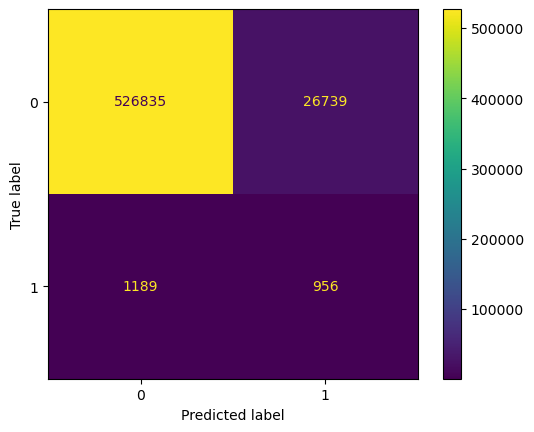

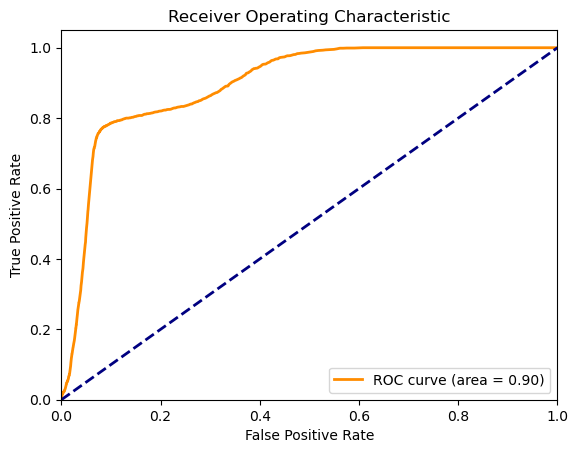

In [39]:
measure_metrics(y_test_actual, y_pred_rf_smote_tuned, y_prob_rf_smote_tuned)